# Eficiência Energética — Previsão de Heating Load (Y1)
**Integrantes:** Vicente Piltcher, Ghabriel Molina, Michele Ughini

Dataset: [Energy Efficiency — UCI ML Repository](https://archive.ics.uci.edu/dataset/242/energy+efficiency)

**Objetivo:** Prever Y1 (Heating Load) usando k-NN e MLP com validação cruzada.

## 1. Importações e Download do Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

import urllib.request
import zipfile
import os

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


In [2]:
# Download do dataset via UCI ML Repository (versão nova da API)
url = 'https://archive.ics.uci.edu/static/public/242/energy+efficiency.zip'
zip_path = 'energy_efficiency.zip'

if not os.path.exists('ENB2012_data.xlsx'):
    print('Baixando dataset...')
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('.')
    print('Download e extração concluídos.')
else:
    print('Dataset já disponível localmente.')

Baixando dataset...
Download e extração concluídos.


## 2. Carregamento e Análise Exploratória

In [4]:
df = pd.read_excel('ENB2012_data.xlsx')

# Renomear colunas para clareza
df.columns = [
    'X1_Compactness', 'X2_SurfaceArea', 'X3_WallArea', 'X4_RoofArea',
    'X5_Height', 'X6_Orientation', 'X7_GlazingArea', 'X8_GlazingDist',
    'Y1_HeatingLoad', 'Y2_CoolingLoad'
]

print(f'Shape: {df.shape}')
df.head()

Shape: (768, 10)


,X1_Compactness,X2_SurfaceArea,X3_WallArea,X4_RoofArea,X5_Height,X6_Orientation,X7_GlazingArea,X8_GlazingDist,Y1_HeatingLoad,Y2_CoolingLoad
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [5]:
print('=== Estatísticas Descritivas ===')
df.describe().round(3)

=== Estatísticas Descritivas ===


,X1_Compactness,X2_SurfaceArea,X3_WallArea,X4_RoofArea,X5_Height,X6_Orientation,X7_GlazingArea,X8_GlazingDist,Y1_HeatingLoad,Y2_CoolingLoad
count,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000
mean,0.764,671.708,318.500,176.604,5.250,3.500,0.234,2.812,22.307,24.588
std,0.106,88.086,43.626,45.166,1.751,1.119,0.133,1.551,10.090,9.513
min,0.620,514.500,245.000,110.250,3.500,2.000,0.000,0.000,6.010,10.900
25%,0.682,606.375,294.000,140.875,3.500,2.750,0.100,1.750,12.992,15.620
50%,0.750,673.750,318.500,183.750,5.250,3.500,0.250,3.000,18.950,22.080
75%,0.830,741.125,343.000,220.500,7.000,4.250,0.400,4.000,31.668,33.132
max,0.980,808.500,416.500,220.500,7.000,5.000,0.400,5.000,43.100,48.030


In [6]:
print('=== Valores Nulos ===')
print(df.isnull().sum())
print(f'\nTotal de amostras: {len(df)}')

=== Valores Nulos ===
X1_Compactness    0
X2_SurfaceArea    0
X3_WallArea       0
X4_RoofArea       0
X5_Height         0
X6_Orientation    0
X7_GlazingArea    0
X8_GlazingDist    0
Y1_HeatingLoad    0
Y2_CoolingLoad    0
dtype: int64

Total de amostras: 768


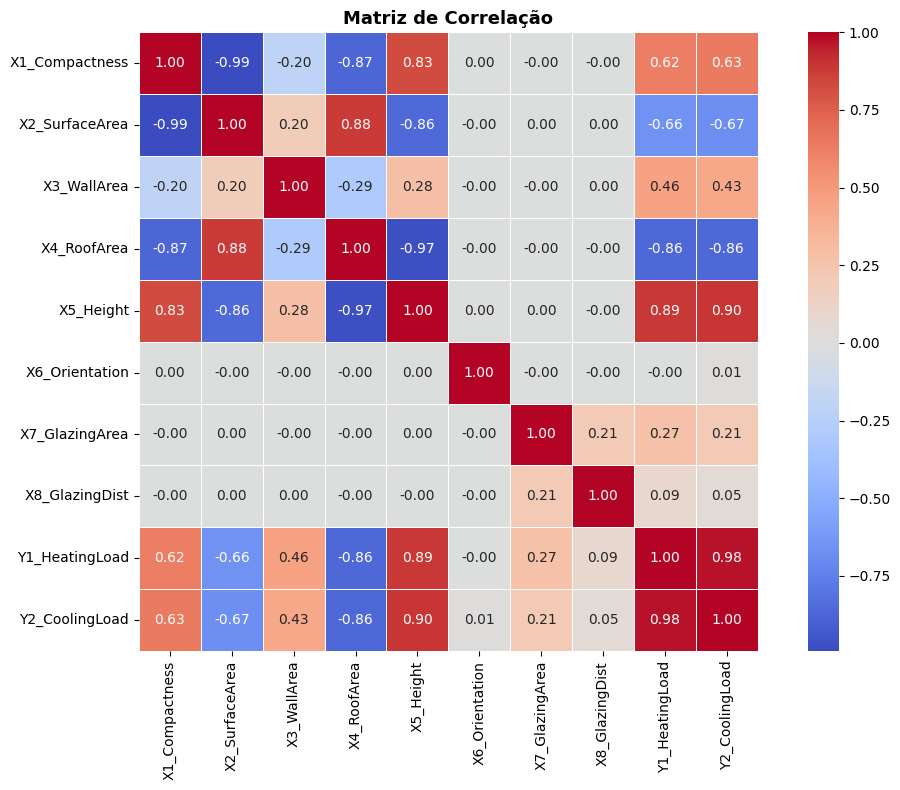

In [8]:
plt.figure(figsize=(11, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Matriz de Correlação', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Pré-processamento

In [9]:
# Separa a features (X) do= alvo (Y1 — Heating Load)
feature_cols = [c for c in df.columns if c.startswith('X')]
X = df[feature_cols].values
y = df['Y1_HeatingLoad'].values

print(f'Features: {feature_cols}')
print(f'X shape: {X.shape}, y shape: {y.shape}')
print(f'Y1 — min: {y.min():.2f}, max: {y.max():.2f}, média: {y.mean():.2f}')

Features: ['X1_Compactness', 'X2_SurfaceArea', 'X3_WallArea', 'X4_RoofArea', 'X5_Height', 'X6_Orientation', 'X7_GlazingArea', 'X8_GlazingDist']
X shape: (768, 8), y shape: (768,)
Y1 — min: 6.01, max: 43.10, média: 22.31


In [10]:
# Divisão treino/teste (80/20) com random seed para aumentar a entropia e complexidade.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')

Treino: 614 amostras | Teste: 154 amostras


In [11]:
# Normalização
scaler_X = MinMaxScaler()
X_train_norm = scaler_X.fit_transform(X_train)
X_test_norm  = scaler_X.transform(X_test)

# Normalização da saída (Melhor pra MLP)
scaler_y = MinMaxScaler()
y_train_norm = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_norm  = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

print('Normalização concluída.')
print(f'X_train_norm — min: {X_train_norm.min():.2f}, max: {X_train_norm.max():.2f}')
print(f'y_train_norm — min: {y_train_norm.min():.2f}, max: {y_train_norm.max():.2f}')

Normalização concluída.
X_train_norm — min: 0.00, max: 1.00
y_train_norm — min: 0.00, max: 1.00


## 4. k-NN com Validação Cruzada e Grid Search

In [12]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Grid search para k (número de vizinhos)
param_grid_knn = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_gs = GridSearchCV(
    KNeighborsRegressor(),
    param_grid_knn,
    cv=kf,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)
knn_gs.fit(X_train_norm, y_train_norm)

print(f'Melhores parâmetros k-NN: {knn_gs.best_params_}')
best_cv_rmse_knn = np.sqrt(-knn_gs.best_score_)
print(f'Melhor RMSE CV (normalizado): {best_cv_rmse_knn:.4f}')

Melhores parâmetros k-NN: {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}
Melhor RMSE CV (normalizado): 0.0414


## 5. MLP com Validação Cruzada e Grid Search

In [15]:
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50), (100, 100)],
    'activation': ['relu', 'tanh'],
    'max_iter': [2000],
    'learning_rate_init': [0.01, 0.001],
    'random_state': [42]
}

mlp_gs = GridSearchCV(
    MLPRegressor(),
    param_grid_mlp,
    cv=kf,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)
mlp_gs.fit(X_train_norm, y_train_norm)

print(f'Melhores parâmetros MLP: {mlp_gs.best_params_}')
best_cv_rmse_mlp = np.sqrt(-mlp_gs.best_score_)
print(f'Melhor RMSE CV (normalizado): {best_cv_rmse_mlp:.4f}')

Melhores parâmetros MLP: {'activation': 'relu', 'hidden_layer_sizes': (100, 100), 'learning_rate_init': 0.01, 'max_iter': 2000, 'random_state': 42}
Melhor RMSE CV (normalizado): 0.0713


## 6. Avaliação no Conjunto de Teste

In [16]:
def avaliar_modelo(nome, modelo, X_tr, y_tr, X_te, y_te, scaler_y):
    """Treina o modelo, prediz no teste e retorna métricas na escala original."""
    modelo.fit(X_tr, y_tr)
    y_pred_norm = modelo.predict(X_te)

    # Reverter normalização
    y_pred = scaler_y.inverse_transform(y_pred_norm.reshape(-1, 1)).ravel()
    y_real = scaler_y.inverse_transform(y_te.reshape(-1, 1)).ravel()

    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae  = mean_absolute_error(y_real, y_pred)
    r2   = r2_score(y_real, y_pred)

    print(f'--- {nome} ---')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  MAE  : {mae:.4f}')
    print(f'  R2   : {r2:.4f}')
    return y_pred, y_real, {'nome': nome, 'RMSE': rmse, 'MAE': mae, 'R2': r2}


knn_best = knn_gs.best_estimator_
mlp_best = mlp_gs.best_estimator_

y_pred_knn, y_real, metricas_knn = avaliar_modelo(
    'k-NN', knn_best, X_train_norm, y_train_norm, X_test_norm, y_test_norm, scaler_y
)
print()
y_pred_mlp, _,      metricas_mlp = avaliar_modelo(
    'MLP',  mlp_best, X_train_norm, y_train_norm, X_test_norm, y_test_norm, scaler_y
)

--- k-NN ---
  RMSE : 1.4419
  MAE  : 1.0104
  R²   : 0.9801

--- MLP ---
  RMSE : 2.8488
  MAE  : 1.8418
  R²   : 0.9221


## 7. Visualizações Comparativas

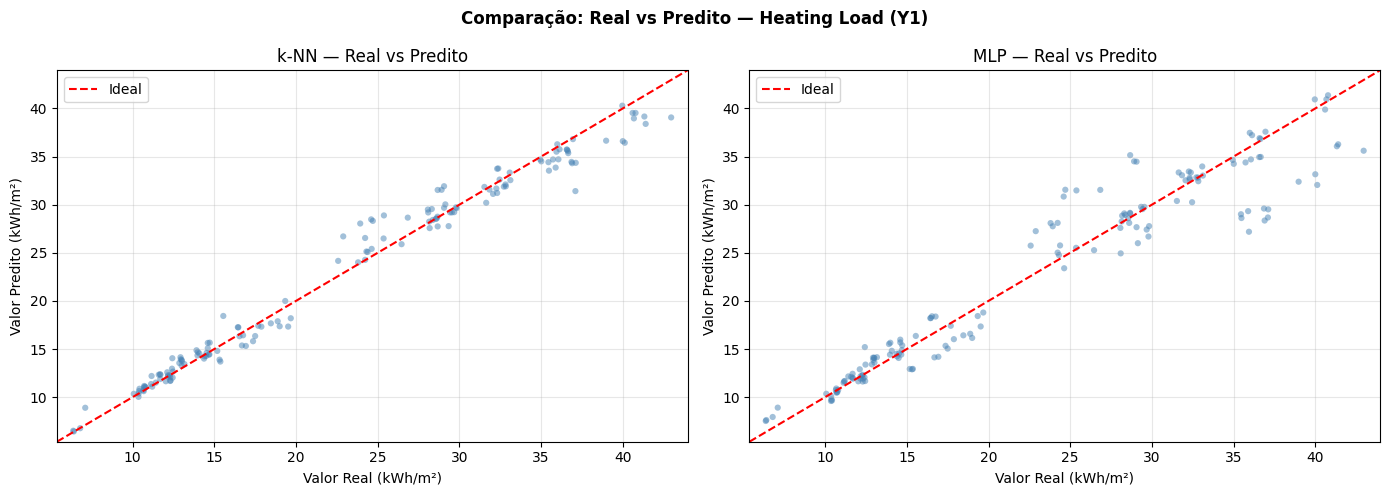

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, titulo in zip(axes,
                               [y_pred_knn, y_pred_mlp],
                               ['k-NN', 'MLP']):
    ax.scatter(y_real, y_pred, alpha=0.5, s=20, color='steelblue', edgecolors='none')
    lim = [min(y_real.min(), y_pred.min()) - 1,
           max(y_real.max(), y_pred.max()) + 1]
    ax.plot(lim, lim, 'r--', linewidth=1.5, label='Ideal')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Valor Real (kWh/m²)')
    ax.set_ylabel('Valor Predito (kWh/m²)')
    ax.set_title(f'{titulo} — Real vs Predito')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Comparação: Real vs Predito — Heating Load (Y1)', fontweight='bold')
plt.tight_layout()
plt.show()

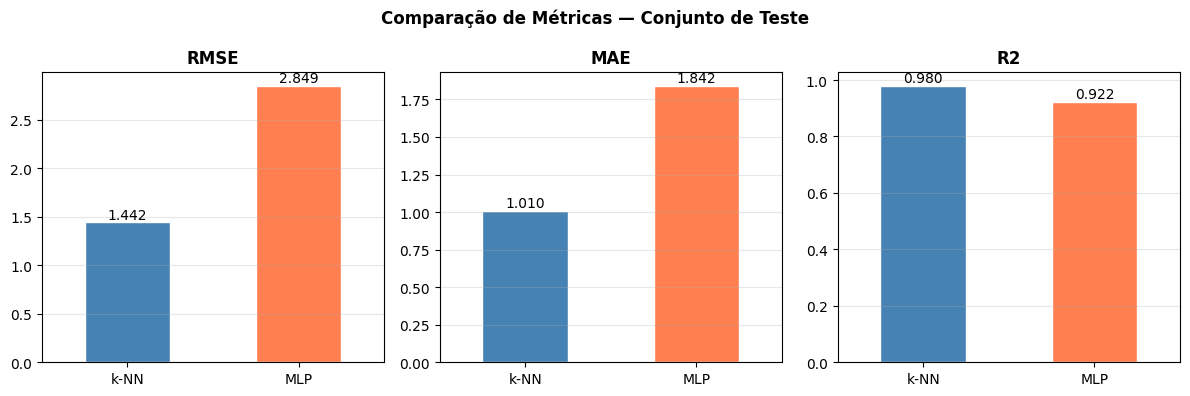

In [19]:
# Gráfico de barras comparando métricas
metricas_df = pd.DataFrame([metricas_knn, metricas_mlp]).set_index('nome')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
cores = ['steelblue', 'coral']

for ax, metrica in zip(axes, ['RMSE', 'MAE', 'R2']):
    metricas_df[metrica].plot(kind='bar', ax=ax, color=cores, edgecolor='white', width=0.5)
    ax.set_title(metrica, fontweight='bold')
    ax.set_xticklabels(metricas_df.index, rotation=0)
    ax.set_xlabel('')
    ax.grid(True, axis='y', alpha=0.3)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=10)

plt.suptitle('Comparação de Métricas — Conjunto de Teste', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Resumo e Conclusão

**Pré-processamento:**
- As features foram normalizadas com `MinMaxScaler` ajustado exclusivamente no conjunto de treino para evitar *data leakage*.
- A saída Y1 também foi normalizada para [0, 1], o que melhora a convergência da MLP e coloca ambos os modelos em condições comparáveis durante a validação cruzada.
- Não havia valores nulos no dataset.

**Validação cruzada:**
- Utilizou-se `KFold` com 10 folds e `GridSearchCV` para encontrar os melhores hiperparâmetros de cada modelo de forma sistemática.

**Comparação k-NN vs MLP:**
- O k-NN é simples, não paramétrico, mas sensível à escala (por isso a normalização é fundamental) e ao valor de k.
- A MLP é capaz de aprender representações não-lineares mais complexas, o que tende a resultar em melhor desempenho para este dataset com 8 features.
- O modelo com menor RMSE e maior R2 no conjunto de teste é considerado o melhor.

**Pré-processamento:**
- As features foram normalizadas com `MinMaxScaler` ajustado exclusivamente no conjunto de treino para evitar *data leakage*.
- A saída Y1 também foi normalizada para [0, 1], o que melhora a convergência da MLP e coloca ambos os modelos em condições comparáveis durante a validação cruzada.
- Não havia valores nulos no dataset.

**Validação cruzada:**
- Utilizou-se `KFold` com 10 folds e `GridSearchCV` para encontrar os melhores hiperparâmetros de cada modelo de forma sistemática.

**Comparação k-NN vs MLP:**
- O k-NN é simples, não paramétrico, mas sensível à escala (por isso a normalização é fundamental) e ao valor de k.
- A MLP é capaz de aprender representações não-lineares mais complexas, o que tende a resultar em melhor desempenho para este dataset com 8 features.
- O modelo com menor RMSE e maior R2 no conjunto de teste é considerado o melhor.